# Euro500 Index Returns

Dieses Notebook enthält die Schritte 4–7 aus `Euro500_Portfolio` zur Berechnung des EURO500-Market-Returns und zum Vergleich mit STOXX-Benchmarks.


In [ ]:
# --- Imports & configuration ---
from pathlib import Path
import pandas as pd
import numpy as np
import lseg.data as ld
import warnings
BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
(DATA_DIR := BASE_DIR / "intermediate").mkdir(parents=True, exist_ok=True)
(CACHE_DATA_DIR := BASE_DIR / "cache").mkdir(parents=True, exist_ok=True)
warnings.filterwarnings(
    "ignore",
    message=r".*Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe"
)

In [2]:
# --- Prerequisite data for Step 4 ---
EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"Missing file: {EURO500_PATH}")
euro500 = pd.read_parquet(EURO500_PATH).copy()
print("Loaded:", EURO500_PATH)
print("Rows:", len(euro500))


Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
Rows: 56500


## 1. Free-Float Market-Cap Weighted Index (Quarterly Rebalanced)

Portfolio construction:
- Compute constituent weights from free-float market cap at rebalance dates
- Hold weights within quarter
- Rebalance at the next quarter-end

Economic interpretation:
- A broad large-cap euro-area market proxy with time-varying composition.


In [11]:
def build_quarterly_ff_weights(euro500_df: pd.DataFrame) -> pd.DataFrame:
    required_base = ["quarter", "date", "effective_date", "mcap_eur", "FreeFloatPct"]
    missing_base = [c for c in required_base if c not in euro500_df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns for weight build: {missing_base}")

    w = euro500_df.copy()

    # Backward compatibility: build firm_id if not yet present in loaded euro500.
    if "firm_id" not in w.columns:
        out = pd.Series(pd.NA, index=w.index, dtype="string")

        if "ISIN" in w.columns:
            v = w["ISIN"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("ISIN:" + v)

        if "RIC_current" in w.columns:
            v = w["RIC_current"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "RIC" in w.columns:
            v = w["RIC"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "SEDOL" in w.columns:
            v = w["SEDOL"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("SEDOL:" + v)

        w["firm_id"] = out

    w["mcap_eur"] = pd.to_numeric(w["mcap_eur"], errors="coerce")
    w["FreeFloatPct"] = pd.to_numeric(w["FreeFloatPct"], errors="coerce")
    w["firm_id"] = w["firm_id"].astype("string").str.strip()
    w = w[w["firm_id"].notna() & (w["firm_id"] != "")].copy()

    # Supports both 0-100 and 0-1 free-float formats.
    ff_raw = pd.to_numeric(w["FreeFloatPct"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
    ff_frac = np.where(ff_raw > 1.0, ff_raw / 100.0, ff_raw)
    w["ff_frac_used"] = pd.Series(ff_frac, index=w.index).clip(lower=0.0, upper=1.0)
    w["ff_frac_used"] = w["ff_frac_used"].fillna(1.0)

    w["ff_mcap_eur"] = w["mcap_eur"] * w["ff_frac_used"]
    w = w.dropna(subset=["ff_mcap_eur"]).copy()

    # Keep one line per quarter + firm_id (largest ff_mcap if duplicates exist).
    w = (
        w.sort_values(["quarter", "firm_id", "ff_mcap_eur"], ascending=[True, True, False])
        .drop_duplicates(subset=["quarter", "firm_id"], keep="first")
        .copy()
    )

    q_sum = w.groupby("quarter")["ff_mcap_eur"].transform("sum")
    w["weight_ff_mcap"] = np.where(q_sum > 0, w["ff_mcap_eur"] / q_sum, np.nan)

    out_cols = [
        "quarter",
        "date",
        "effective_date",
        "firm_id",
        "ISIN",
        "RIC",
        "name",
        "mcap_eur",
        "FreeFloatPct",
        "ff_frac_used",
        "ff_mcap_eur",
        "weight_ff_mcap",
        "rank_mcap",
    ]
    out_cols = [c for c in out_cols if c in w.columns]
    out = w[out_cols].sort_values(["quarter", "weight_ff_mcap"], ascending=[True, False]).reset_index(drop=True)
    return out


weights_ff = build_quarterly_ff_weights(euro500)

weights_qc = (
    weights_ff.groupby("quarter", as_index=False)
    .agg(
        n_constituents=("firm_id", "nunique"),
        weight_sum=("weight_ff_mcap", "sum"),
        ff_mcap_total=("ff_mcap_eur", "sum"),
    )
)
print("Quarterly weights quality check:")
display(weights_qc.head())
display(weights_qc.tail())



Quarterly weights quality check:


,quarter,n_constituents,weight_sum,ff_mcap_total
0,1998Q1,500,1.0,924974824254.137695
1,1998Q2,500,1.0,1368704672100.7146
2,1998Q3,500,1.0,1485947193115.250488
3,1998Q4,500,1.0,1152769034853.703857
4,1999Q1,500,1.0,1362409800770.108887


,quarter,n_constituents,weight_sum,ff_mcap_total
108,2025Q1,500,1.0,5681777172798.492188
109,2025Q2,500,1.0,6110905809377.236328
110,2025Q3,500,1.0,6318190626598.301758
111,2025Q4,500,1.0,6544643949657.299805
112,2026Q1,500,1.0,6843051270078.774414


## 2. Daily Market Return from In-Index Daily Company Returns (with €STR Risk-Free)

This step maps daily stock returns to index membership periods.

Method:
- Keep each firm's daily returns only while it is in the index
- Aggregate to a daily portfolio return using quarterly weights

Output:
- Clean daily return series for the EURO500 portfolio.


In [12]:
RETURNS_IN_INDEX_PATH = DATA_DIR / "euro500_daily_returns.parquet"
if not RETURNS_IN_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing file: {RETURNS_IN_INDEX_PATH}")

returns_in_index = pd.read_parquet(RETURNS_IN_INDEX_PATH)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["ret"] = pd.to_numeric(returns_in_index["ret"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype(str)


def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("SEDOL:" + v)

    return out


if "firm_id" in returns_in_index.columns:
    returns_in_index["firm_id"] = returns_in_index["firm_id"].astype("string").str.strip()
    returns_in_index.loc[returns_in_index["firm_id"] == "", "firm_id"] = pd.NA
    # keep existing firm_id (expected: stable FIRMxxxx ids) and only fill true missing values
    returns_in_index["firm_id"] = returns_in_index["firm_id"].fillna(_build_firm_id(returns_in_index))
else:
    returns_in_index["firm_id"] = _build_firm_id(returns_in_index)

weights_join = weights_ff[["quarter", "firm_id", "weight_ff_mcap"]].copy()
weights_join["quarter"] = weights_join["quarter"].astype(str)
weights_join["firm_id"] = weights_join["firm_id"].astype(str).str.strip()

idx_daily = returns_in_index.merge(
    weights_join,
    on=["quarter", "firm_id"],
    how="inner",
)
idx_daily = idx_daily.dropna(subset=["date", "ret", "weight_ff_mcap"]).copy()
idx_daily["weighted_ret"] = idx_daily["ret"] * idx_daily["weight_ff_mcap"]

market_daily = (
    idx_daily
    .groupby(["date", "quarter"], as_index=False)
    .agg(
        market_return_num=("weighted_ret", "sum"),
        weight_available=("weight_ff_mcap", "sum"),
        n_constituents_with_return=("firm_id", "nunique"),
    )
)
market_daily["market_return_ffmcap"] = np.where(
    market_daily["weight_available"] > 0,
    market_daily["market_return_num"] / market_daily["weight_available"],
    np.nan,
)
MIN_WEIGHT_AVAILABLE = 0.80
market_daily["market_return_ffmcap_capped80"] = np.where(
    market_daily["weight_available"] >= MIN_WEIGHT_AVAILABLE,
    market_daily["market_return_ffmcap"],
    np.nan,
)

market_daily = market_daily.sort_values(["date", "quarter"]).reset_index(drop=True)
market_daily_out = market_daily[[
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
    "n_constituents_with_return",
]]

# --- Daily risk-free rate (EUR): EUR Short-Term Rate (€STR) ---
RF_CACHE_DIR = CACHE_DATA_DIR / "rf_cache"
RF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RF_CACHE_SCHEMA_VERSION = "v2"


def _rf_cache_path(start: pd.Timestamp, end: pd.Timestamp) -> Path:
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return RF_CACHE_DIR / f"rf_estr_{RF_CACHE_SCHEMA_VERSION}_{s}_{e}.parquet"


def _coerce_num(s: pd.Series) -> pd.Series:
    t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
    t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
    return pd.to_numeric(t, errors="coerce")


def _api_date_value_cols(df: pd.DataFrame) -> tuple[str, str]:
    date_candidates = [c for c in df.columns if "TIME" in c.upper() and "PERIOD" in c.upper()]
    value_candidates = [c for c in df.columns if c.upper() in {"OBS_VALUE", "OBSVALUE", "VALUE"}]
    if not date_candidates or not value_candidates:
        raise ValueError(f"ECB API response schema unexpected. Columns={list(df.columns)}")
    return date_candidates[0], value_candidates[0]


def _to_daily_rate(out: pd.DataFrame, annual_col: str) -> pd.DataFrame:
    out = out.dropna(subset=["date", annual_col]).sort_values("date")
    if out.empty:
        return out

    good = out[annual_col] > -1.0
    out["rf_daily"] = np.nan
    out.loc[good, "rf_daily"] = np.expm1(np.log1p(out.loc[good, annual_col]) / 360.0)
    return out


def _pull_ecb_est(start_str: str, end_str: str) -> pd.DataFrame:
    # €STR (annualized % rate)
    ecb_series = "EST.B.EU000A2X2A25.WT"
    ecb_url = (
        "https://data-api.ecb.europa.eu/service/data/EST/B.EU000A2X2A25.WT"
        f"?startPeriod={start_str}&endPeriod={end_str}&format=csvdata"
    )
    df = pd.read_csv(ecb_url)
    dcol, vcol = _api_date_value_cols(df)
    out = pd.DataFrame({
        "date": pd.to_datetime(df[dcol], errors="coerce"),
        "rf_annual": pd.to_numeric(df[vcol], errors="coerce") / 100.0,
    })
    out["rf_source"] = "€STR"
    return _to_daily_rate(out, annual_col="rf_annual")


def _pull_ecb_eonia(start_str: str, end_str: str) -> pd.DataFrame:
    # EONIA (historical overnight benchmark, annualized %).
    # We query dataset-level CSV and isolate the central EONIA rate series.
    ecb_url = (
        "https://data-api.ecb.europa.eu/service/data/EON"
        f"?startPeriod={start_str}&endPeriod={end_str}&format=csvdata"
    )
    df = pd.read_csv(ecb_url)
    dcol, vcol = _api_date_value_cols(df)

    text_cols = [c for c in df.columns if c not in {dcol, vcol}]
    joined = (
        df[text_cols].astype(str).fillna("").agg(" ".join, axis=1).str.upper()
        if text_cols else pd.Series([""] * len(df))
    )

    mask_core = joined.str.contains("EONIA", na=False)
    mask_excl = joined.str.contains("25PCT|75PCT|VOLUME|VOL", na=False, regex=True)
    m = mask_core & (~mask_excl)
    dfx = df.loc[m].copy() if m.any() else df.copy()

    # If multiple series remain, keep the one with most observations.
    series_cols = [c for c in dfx.columns if c not in {dcol, vcol}]
    if series_cols:
        cnt = (
            dfx.assign(__k=dfx[series_cols].astype(str).agg("|".join, axis=1))
            .groupby("__k", as_index=False)[vcol]
            .count()
            .sort_values(vcol, ascending=False)
        )
        if not cnt.empty:
            best = cnt.iloc[0]["__k"]
            dfx = dfx[dfx[series_cols].astype(str).agg("|".join, axis=1) == best].copy()

    out = pd.DataFrame({
        "date": pd.to_datetime(dfx[dcol], errors="coerce"),
        "rf_annual": pd.to_numeric(dfx[vcol], errors="coerce") / 100.0,
    })
    out["rf_source"] = "EONIA"
    return _to_daily_rate(out, annual_col="rf_annual")


def pull_estr_daily(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid rf date bounds: start={start}, end={end}")

    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")

    try:
        est = _pull_ecb_est(start_str=start_str, end_str=end_str)
    except Exception as e:
        raise ValueError(f"ECB €STR pull failed: {type(e).__name__}: {e}")

    try:
        eon = _pull_ecb_eonia(start_str=start_str, end_str=end_str)
    except Exception:
        # If EONIA lookup fails, keep pure €STR (short history).
        eon = pd.DataFrame(columns=["date", "rf_annual", "rf_daily", "rf_source"])

    # Splice rule: use €STR where available; otherwise fallback to EONIA.
    rf = pd.concat([eon, est], ignore_index=True)
    rf = rf.dropna(subset=["date"]).sort_values(["date", "rf_source"]).copy()

    # prefer €STR over EONIA on overlapping dates
    prio = {"EONIA": 0, "€STR": 1}
    rf["_prio"] = rf["rf_source"].map(prio).fillna(0)
    rf = rf.sort_values(["date", "_prio"]).drop_duplicates(subset=["date"], keep="last")

    rf["ric_used"] = "ECB:EST.B.EU000A2X2A25.WT + EON(dataset)"
    rf["field_used"] = "OBS_VALUE"
    rf["rf_estr_annual"] = rf["rf_annual"]

    return rf[["date", "rf_estr_annual", "rf_daily", "ric_used", "field_used", "rf_source"]].sort_values("date").reset_index(drop=True)


def pull_estr_daily_cached(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    cache_path = _rf_cache_path(start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"RF cache hit: {cache_path.name}")
        return out

    print("RF cache miss -> pulling €STR from ECB API")
    out = pull_estr_daily(start=start, end=end)

    out.to_parquet(cache_path, index=False)
    return out


date_min = pd.to_datetime(market_daily_out["date"], errors="coerce").min()
date_max = pd.to_datetime(market_daily_out["date"], errors="coerce").max()
rf_df = pull_estr_daily_cached(start=date_min, end=date_max)
rf_keep_cols = [c for c in ["date", "rf_estr_annual", "rf_daily", "rf_source"] if c in rf_df.columns]
rf_df = rf_df[rf_keep_cols].drop_duplicates(subset=["date"])

market_daily_out = market_daily_out.merge(rf_df, on="date", how="left")
market_daily_out["excess_market_return_ffmcap"] = (
    market_daily_out["market_return_ffmcap"] - market_daily_out["rf_daily"]
)
market_daily_out["excess_market_return_ffmcap_capped80"] = (
    market_daily_out["market_return_ffmcap_capped80"] - market_daily_out["rf_daily"]
)

print("Saved daily market return series.")
print("Date range:", market_daily_out["date"].min(), "to", market_daily_out["date"].max())
print("Mean daily weight available:", round(float(market_daily_out["weight_available"].mean()), 4))
print(
    "Days dropped by 80% availability cap:",
    int(market_daily_out["market_return_ffmcap_capped80"].isna().sum()),
)
display(market_daily_out.head())
display(market_daily_out.tail())



RF cache hit: rf_estr_v2_19980102_20250930.parquet
Saved daily market return series.
Date range: 1998-01-02 00:00:00 to 2025-09-30 00:00:00
Mean daily weight available: 0.97
Days dropped by 80% availability cap: 98


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return,rf_estr_annual,rf_daily,rf_source,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80
0,1998-01-02,1998Q1,0.027136,0.027136,0.970649,407,NaN,NaN,NaN,NaN,NaN
1,1998-01-05,1998Q1,0.019075,0.019075,0.963910,420,NaN,NaN,NaN,NaN,NaN
2,1998-01-06,1998Q1,-0.005882,NaN,0.694494,286,NaN,NaN,NaN,NaN,NaN
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970215,422,NaN,NaN,NaN,NaN,NaN
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971234,424,NaN,NaN,NaN,NaN,NaN


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return,rf_estr_annual,rf_daily,rf_source,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80
7115,2025-09-24,2025Q3,-0.001161,-0.001161,0.98600,480,0.01928,0.000053,€STR,-0.001214,-0.001214
7116,2025-09-25,2025Q3,-0.004294,-0.004294,0.98565,480,0.01927,0.000053,€STR,-0.004347,-0.004347
7117,2025-09-26,2025Q3,0.008264,0.008264,0.98558,480,0.01926,0.000053,€STR,0.008211,0.008211
7118,2025-09-29,2025Q3,0.002185,0.002185,0.98601,481,0.01926,0.000053,€STR,0.002132,0.002132
7119,2025-09-30,2025Q3,0.004428,0.004428,0.98559,481,0.01916,0.000053,€STR,0.004375,0.004375


## 3. Market Index Diagnostics

Quality checks on the constructed return index, e.g.:
- Return distribution and outliers
- Coverage through time
- Missingness and continuity

Purpose:
- Confirm the index is empirically stable before benchmark comparison.


Market index diagnostics:
  obs_days: 7120
  start: 1998-01-02 00:00:00
  end: 2025-09-30 00:00:00
  mean_daily_return: 0.0004882934245929228
  vol_daily_return: 0.013888029370578503
  mean_daily_return_capped80: 0.00039701462468010366
  vol_daily_return_capped80: 0.013249382558286782
  mean_weight_available: 0.9700092029348067
  p5_weight_available: 0.88440135446903
  mean_constituents_with_return: 466.74143258426966


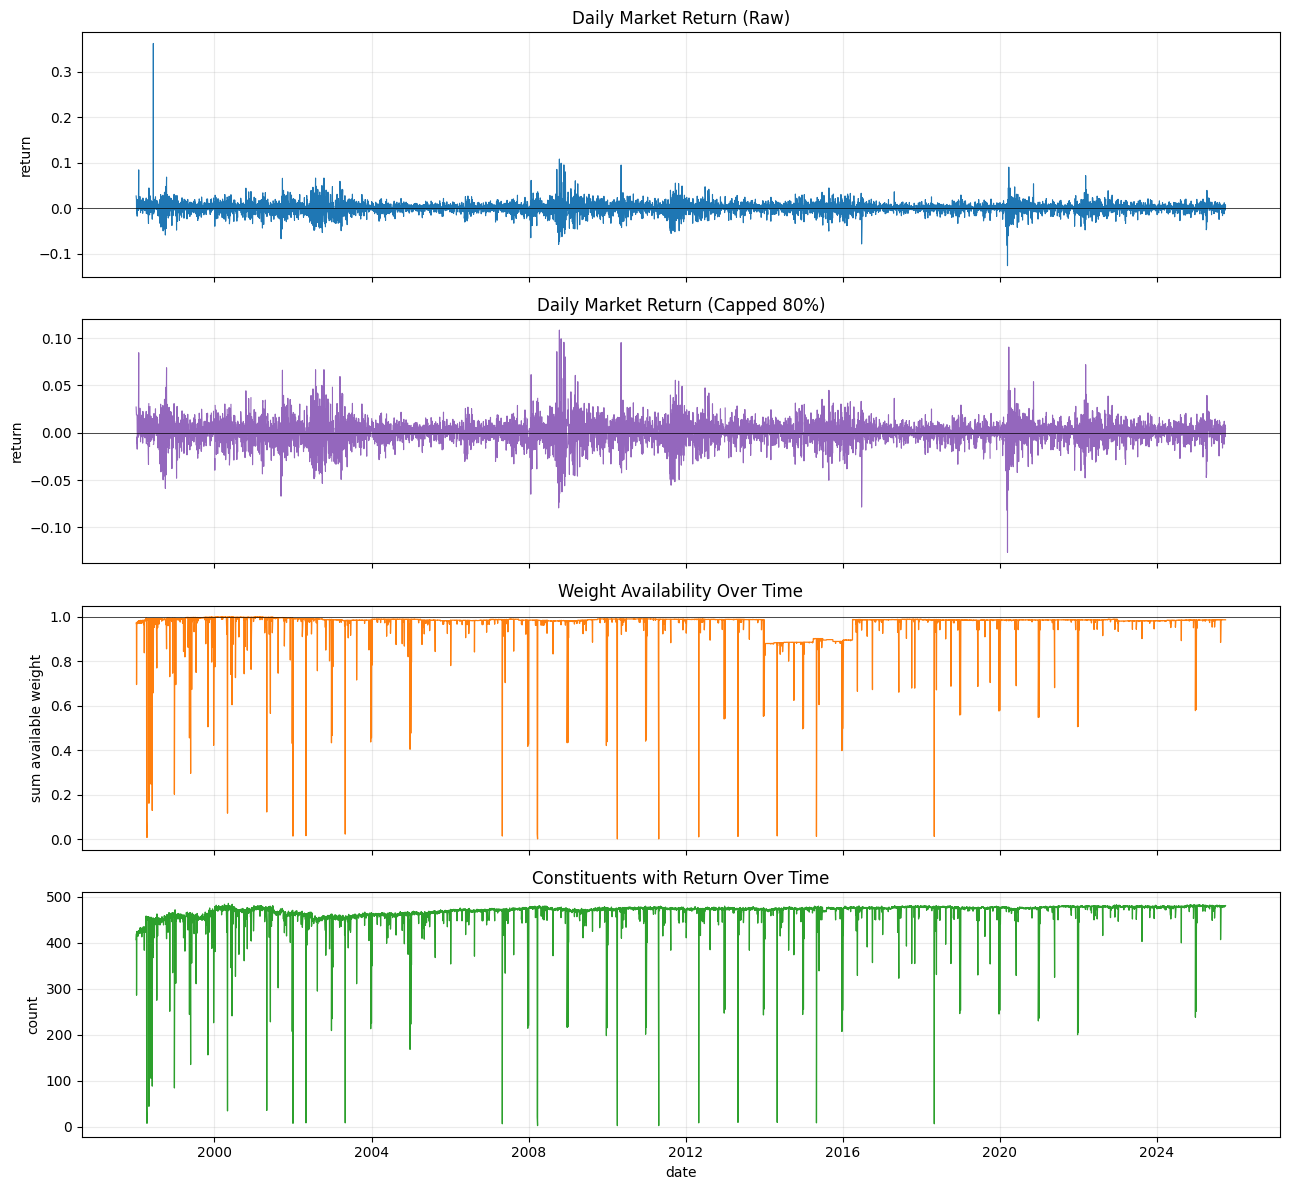

Worst 10 days by market return:


,date,quarter,market_return_ffmcap,weight_available,n_constituents_with_return
5696,2020-03-12,2020Q1,-0.126260,0.984196,476
5693,2020-03-09,2020Q1,-0.082038,0.984247,476
2763,2008-10-06,2008Q4,-0.079353,0.978657,473
4745,2016-06-24,2016Q2,-0.078469,0.939095,454
2767,2008-10-10,2008Q4,-0.073263,0.978020,473
949,2001-09-11,2001Q3,-0.066962,0.994984,468
2579,2008-01-21,2008Q1,-0.064852,0.984051,478
2770,2008-10-15,2008Q4,-0.064330,0.982689,475
2786,2008-11-06,2008Q4,-0.062415,0.981353,470
5698,2020-03-16,2020Q1,-0.060839,0.985118,477


Days with lowest weight availability:


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
3144,2010-04-05,2010Q2,0.023721,NaN,0.000448,2
3418,2011-04-25,2011Q2,0.004230,NaN,0.000613,2
2624,2008-03-24,2008Q1,-0.009919,NaN,0.000641,2
71,1998-04-13,1998Q2,0.000000,NaN,0.007076,7
3681,2012-05-01,2012Q2,0.010464,NaN,0.009725,8
3937,2013-05-01,2013Q2,0.008779,NaN,0.011695,9
5218,2018-05-01,2018Q2,0.004009,NaN,0.011815,6
4449,2015-05-01,2015Q2,0.011996,NaN,0.012009,8
1026,2001-12-31,2001Q4,0.000381,NaN,0.013370,7
2393,2007-05-01,2007Q2,0.003097,NaN,0.013629,6


In [13]:
import matplotlib.pyplot as plt

diag = market_daily_out.copy()
diag["date"] = pd.to_datetime(diag["date"], errors="coerce")
diag = diag.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

stats = {
    "obs_days": int(len(diag)),
    "start": diag["date"].min(),
    "end": diag["date"].max(),
    "mean_daily_return": float(diag["market_return_ffmcap"].mean()),
    "vol_daily_return": float(diag["market_return_ffmcap"].std()),
    "mean_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].mean()),
    "vol_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].std()),
    "mean_weight_available": float(diag["weight_available"].mean()),
    "p5_weight_available": float(diag["weight_available"].quantile(0.05)),
    "mean_constituents_with_return": float(diag["n_constituents_with_return"].mean()),
}
print("Market index diagnostics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(diag["date"], diag["market_return_ffmcap"], lw=0.8, color="tab:blue")
axes[0].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[0].set_title("Daily Market Return (Raw)")
axes[0].set_ylabel("return")
axes[0].grid(alpha=0.25)

axes[1].plot(diag["date"], diag["market_return_ffmcap_capped80"], lw=0.8, color="tab:purple")
axes[1].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[1].set_title("Daily Market Return (Capped 80%)")
axes[1].set_ylabel("return")
axes[1].grid(alpha=0.25)

axes[2].plot(diag["date"], diag["weight_available"], color="tab:orange", lw=0.9)
axes[2].axhline(1.0, color="black", lw=0.7, alpha=0.7)
axes[2].set_title("Weight Availability Over Time")
axes[2].set_ylabel("sum available weight")
axes[2].grid(alpha=0.25)

axes[3].plot(diag["date"], diag["n_constituents_with_return"], color="tab:green", lw=0.9)
axes[3].set_title("Constituents with Return Over Time")
axes[3].set_ylabel("count")
axes[3].set_xlabel("date")
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Worst 10 days by market return:")
display(
    diag.nsmallest(10, "market_return_ffmcap")[
        ["date", "quarter", "market_return_ffmcap", "weight_available", "n_constituents_with_return"]
    ]
)

print("Days with lowest weight availability:")
display(
    diag.nsmallest(10, "weight_available")[
        ["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available", "n_constituents_with_return"]
    ]
)


## 4. Benchmark Pull and Comparison (STOXX 600, STOXX EURO 50)

External benchmark data is pulled to evaluate tracking properties.

Comparison dimensions:
- Level and cumulative return paths
- Correlation and co-movement
- Relative performance across subperiods


In [14]:
def pull_index_daily_return(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """
    Pull daily benchmark returns from LSEG using Total-Return-like fields only.
    """
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid benchmark date bounds for {ric}: start={start}, end={end}")

    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")

    tr_fields = [
        "TR.TotalReturn",
        "TR.IndexTotalReturn",
        "TR.IndexGrossReturn",
        "TR.IndexNetReturn",
    ]
    price_fields = [
        "TR.PriceClose",
        "CLOSE",
    ]

    last_err = None
    tried = []

    def _coerce_num(s: pd.Series) -> pd.Series:
        # Handles values like "0.45%", "1,234.5", etc.
        t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
        t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
        return pd.to_numeric(t, errors="coerce")

    for field in tr_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            # Choose the column that yields the most numeric observations.
            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 0:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if out.empty:
                continue

            # TR-like series can come as percent points or decimals.
            max_abs = out["value"].abs().quantile(0.99)
            out["ret"] = out["value"] / 100.0 if max_abs > 1.5 else out["value"]
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = field
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    # Fallback for return-index RICs (e.g., .STOXXR/.STOXX50ER):
    # use index level (PriceClose/Close) and convert to daily returns.
    # This remains TR-consistent because the RIC itself is a return index.
    for field in price_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 1:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if len(out) <= 1:
                continue

            out["ret"] = out["value"].pct_change()
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = f"{field}->pct_change"
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    msg = f"No usable TR benchmark series for {ric}. Tried fields: {tried}"
    if last_err is not None:
        msg += f" | last error: {type(last_err).__name__}: {last_err}"
    raise ValueError(msg)


# File cache for benchmark pulls to avoid repeated LSEG requests.
BENCH_CACHE_DIR = CACHE_DATA_DIR / "benchmark_cache"
BENCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
BENCH_CACHE_SCHEMA_VERSION = "v2"

def _bench_cache_path(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> Path:
    ric_key = str(ric).replace(".", "_dot_").replace("/", "_")
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return BENCH_CACHE_DIR / f"bench_{BENCH_CACHE_SCHEMA_VERSION}_{ric_key}_{s}_{e}.parquet"

def pull_index_daily_return_cached(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    cache_path = _bench_cache_path(ric=ric, start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"Cache hit: {ric} -> {cache_path.name}")
        return out

    print(f"Cache miss: {ric} -> pulling from LSEG")
    ld.open_session()
    try:
        out = pull_index_daily_return(ric=ric, start=start, end=end)
    finally:
        ld.close_session()

    out.to_parquet(cache_path, index=False)
    return out


def _resolve_benchmark_bounds(min_start: str = "1998-01-01") -> tuple[pd.Timestamp, pd.Timestamp]:
    candidates = []
    min_start_dt = pd.to_datetime(min_start).normalize()

    # Primary source: market index daily output.
    if "market_daily_out" in globals() and isinstance(market_daily_out, pd.DataFrame) and "date" in market_daily_out.columns:
        d = pd.to_datetime(market_daily_out["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "market_daily_out"))

    # Fallback: in-index stock returns.
    if "returns_in_index" in globals() and isinstance(returns_in_index, pd.DataFrame) and "date" in returns_in_index.columns:
        d = pd.to_datetime(returns_in_index["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "returns_in_index"))

    if not candidates:
        raise ValueError("Could not resolve benchmark date bounds (no valid dates in market_daily_out/returns_in_index).")

    # Prefer the first candidate (market_daily_out), otherwise fallback already handled.
    start_dt, end_dt, src = candidates[0]
    start_dt = min(start_dt.normalize(), min_start_dt)
    print(f"Benchmark date bounds from {src} (forced min start {min_start_dt.date()}): {start_dt.date()} -> {end_dt.date()}")
    return start_dt, end_dt


start_dt, end_dt = _resolve_benchmark_bounds()

bench_list = [
    (".STOXXR", "stoxx600_ret"),
    (".STOXX50ER", "stoxx_euro50_ret"),
]

bench_frames = []
bench_meta = []

for ric, col_name in bench_list:
    b = pull_index_daily_return_cached(ric=ric, start=start_dt, end=end_dt).rename(columns={"ret": col_name})
    if b.empty:
        raise ValueError(f"Benchmark pull returned empty frame for {ric}")
    bench_meta.append(
        b[["ric", "field_used", "is_total_return"]]
        .drop_duplicates()
        .assign(series=col_name)
    )
    bench_frames.append(b[["date", col_name]])

bench_info = pd.concat(bench_meta, ignore_index=True)
print("Benchmark fields used:")
display(bench_info)

if len(bench_frames) != len(bench_list):
    raise ValueError("Not all benchmark TR series were pulled successfully (.STOXXR / .STOXX50ER).")

cmp_cols = [
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
]
for c in ["rf_daily", "rf_estr_annual", "excess_market_return_ffmcap", "excess_market_return_ffmcap_capped80"]:
    if c in market_daily_out.columns:
        cmp_cols.append(c)
cmp_df = market_daily_out[cmp_cols].copy()
for bf in bench_frames:
    cmp_df = cmp_df.merge(bf, on="date", how="left")

print("Comparison frame date range:", cmp_df["date"].min(), "to", cmp_df["date"].max())
print("Missing benchmark shares:")
for c in ["stoxx600_ret", "stoxx_euro50_ret"]:
    print(f"  {c}: {cmp_df[c].isna().mean():.2%}")

display(cmp_df.head())
display(cmp_df.tail())





Benchmark date bounds from market_daily_out (forced min start 1998-01-01): 1998-01-01 -> 2025-09-30
Cache hit: .STOXXR -> bench_v2__dot_STOXXR_19980101_20250930.parquet
Cache hit: .STOXX50ER -> bench_v2__dot_STOXX50ER_19980101_20250930.parquet
Benchmark fields used:


,ric,field_used,is_total_return,series
0,.STOXXR,TR.PriceClose->pct_change,True,stoxx600_ret
1,.STOXX50ER,TR.PriceClose->pct_change,True,stoxx_euro50_ret


Comparison frame date range: 1998-01-02 00:00:00 to 2025-09-30 00:00:00
Missing benchmark shares:
  stoxx600_ret: 24.52%
  stoxx_euro50_ret: 24.40%


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,rf_daily,rf_estr_annual,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80,stoxx600_ret,stoxx_euro50_ret
0,1998-01-02,1998Q1,0.027136,0.027136,0.970649,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-01-05,1998Q1,0.019075,0.019075,0.963910,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-01-06,1998Q1,-0.005882,NaN,0.694494,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970215,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971234,NaN,NaN,NaN,NaN,NaN,NaN


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,rf_daily,rf_estr_annual,excess_market_return_ffmcap,excess_market_return_ffmcap_capped80,stoxx600_ret,stoxx_euro50_ret
7115,2025-09-24,2025Q3,-0.001161,-0.001161,0.98600,0.000053,0.01928,-0.001214,-0.001214,-0.001872,-0.001430
7116,2025-09-25,2025Q3,-0.004294,-0.004294,0.98565,0.000053,0.01927,-0.004347,-0.004347,-0.006568,-0.003599
7117,2025-09-26,2025Q3,0.008264,0.008264,0.98558,0.000053,0.01926,0.008211,0.008211,0.008025,0.010596
7118,2025-09-29,2025Q3,0.002185,0.002185,0.98601,0.000053,0.01926,0.002132,0.002132,0.001815,0.001300
7119,2025-09-30,2025Q3,0.004428,0.004428,0.98559,0.000053,0.01916,0.004375,0.004375,0.004771,0.004196


## 5. Relative Performance Views

Additional relative metrics and plots, such as:
- Return spreads vs benchmark
- Rolling excess performance
- Drawdown and recovery comparison


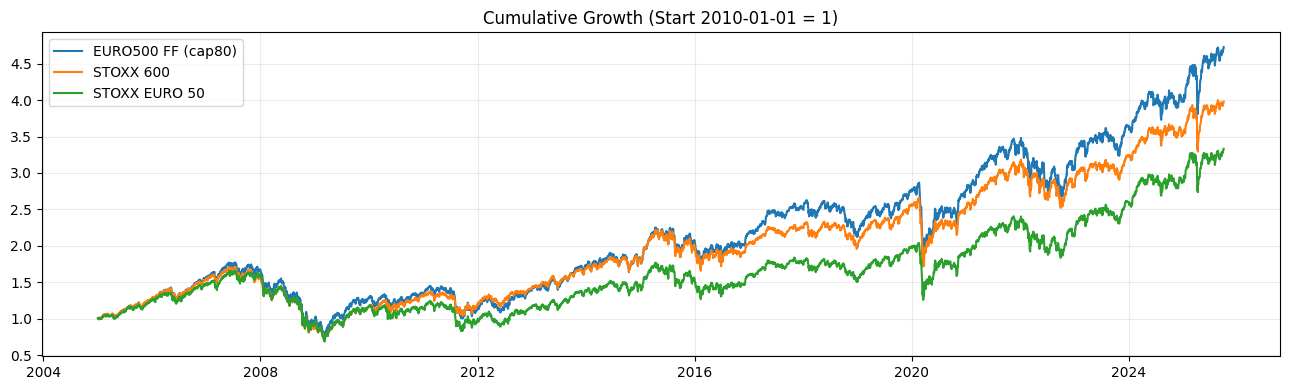

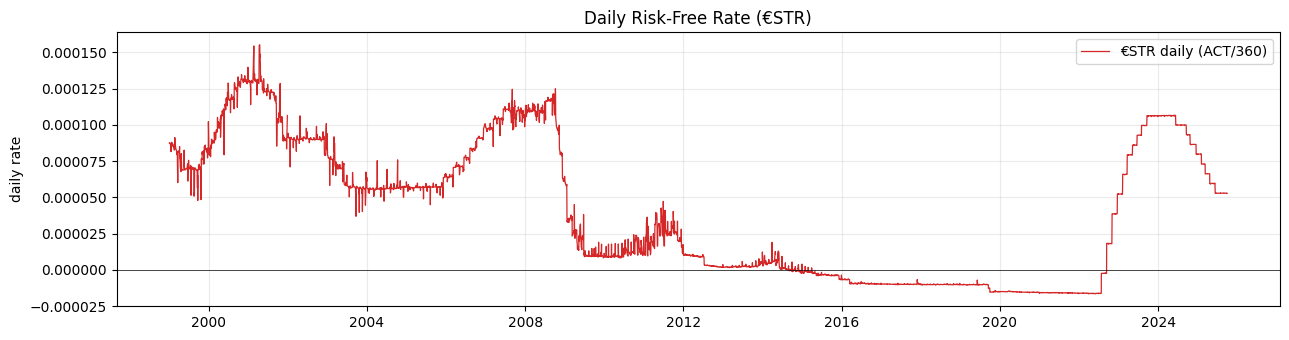

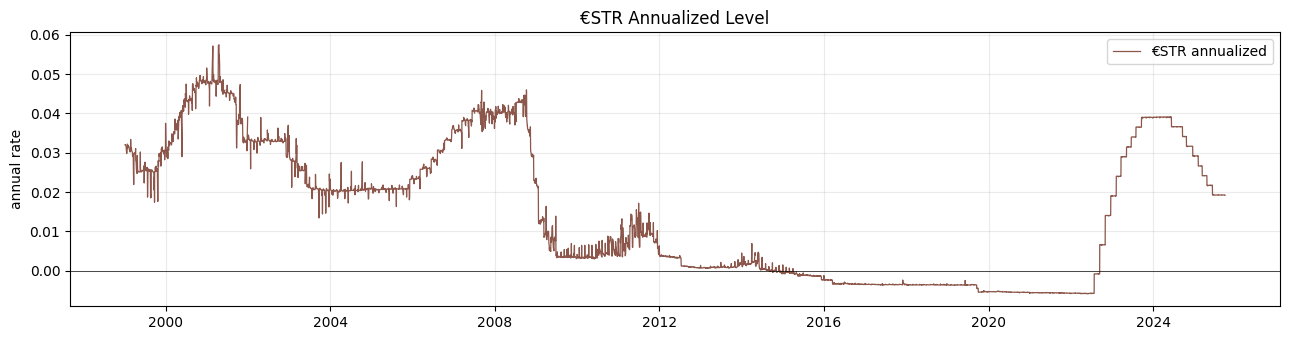

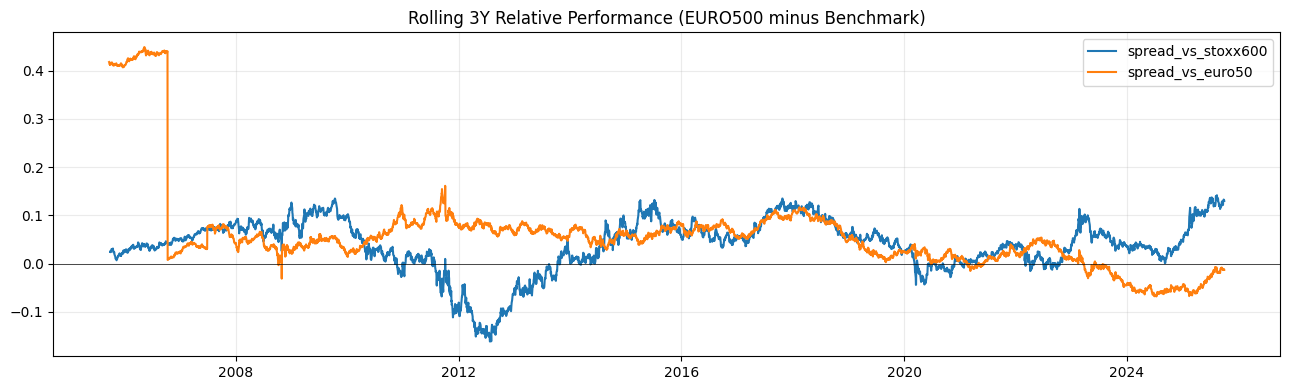

In [15]:
def _normalized_cum_level(ret: pd.Series, base: float = 1.0) -> pd.Series:
    """Convert daily returns into a normalized cumulative level."""
    r = pd.to_numeric(ret, errors="coerce")
    out = (1.0 + r.fillna(0.0)).cumprod() * float(base)
    return out

cmp_plot = cmp_df.copy()
cmp_plot["date"] = pd.to_datetime(cmp_plot["date"], errors="coerce")
cmp_plot = cmp_plot.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

START_NORM = pd.Timestamp("2005-01-01")
cmp_norm = cmp_plot[cmp_plot["date"] >= START_NORM].copy()

series_cols = [
    "market_return_ffmcap_capped80",
    "stoxx600_ret",
    "stoxx_euro50_ret",
]
series_cols = [c for c in series_cols if c in cmp_norm.columns]

for c in series_cols:
    cmp_norm[f"lvl_{c}"] = _normalized_cum_level(cmp_norm[c])

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
if "lvl_market_return_ffmcap_capped80" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_market_return_ffmcap_capped80"], label="EURO500 FF (cap80)")
if "lvl_stoxx600_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx600_ret"], label="STOXX 600")
if "lvl_stoxx_euro50_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx_euro50_ret"], label="STOXX EURO 50")
ax.set_title("Cumulative Growth (Start 2010-01-01 = 1)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# €STR / risk-free diagnostics
if "rf_daily" in cmp_plot.columns and cmp_plot["rf_daily"].notna().any():
    rf_plot = cmp_plot[["date", "rf_daily"]].copy()
    if "rf_estr_annual" in cmp_plot.columns:
        rf_plot["rf_estr_annual"] = cmp_plot["rf_estr_annual"]

    fig, ax = plt.subplots(1, 1, figsize=(13, 3.5))
    ax.plot(rf_plot["date"], rf_plot["rf_daily"], lw=0.9, color="tab:red", label="€STR daily (ACT/360)")
    ax.axhline(0.0, color="black", lw=0.7, alpha=0.7)
    ax.set_title("Daily Risk-Free Rate (€STR)")
    ax.set_ylabel("daily rate")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    if "rf_estr_annual" in rf_plot.columns and rf_plot["rf_estr_annual"].notna().any():
        fig, ax = plt.subplots(1, 1, figsize=(13, 3.5))
        ax.plot(rf_plot["date"], rf_plot["rf_estr_annual"], lw=0.9, color="tab:brown", label="€STR annualized")
        ax.axhline(0.0, color="black", lw=0.7, alpha=0.7)
        ax.set_title("€STR Annualized Level")
        ax.set_ylabel("annual rate")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

# 3Y (756 trading days) rolling relative performance vs benchmarks
rolling_win = 756
rel = cmp_plot[["date", "market_return_ffmcap_capped80"]].copy()
if "stoxx600_ret" in cmp_plot.columns:
    rel["spread_vs_stoxx600"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx600_ret"]
if "stoxx_euro50_ret" in cmp_plot.columns:
    rel["spread_vs_euro50"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx_euro50_ret"]

roll = rel[["date"]].copy()
for c in [x for x in rel.columns if x.startswith("spread_")]:
    # Robust rolling sum: allow partial missing observations but require enough valid days.
    valid_cnt = rel[c].notna().rolling(rolling_win, min_periods=1).sum()
    rsum = rel[c].fillna(0.0).rolling(rolling_win, min_periods=252).sum()
    rsum[valid_cnt < 252] = np.nan
    roll[f"roll3y_{c}"] = rsum

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
for c in [x for x in roll.columns if x.startswith("roll3y_")]:
    ax.plot(roll["date"], roll[c], label=c.replace("roll3y_", ""))
ax.axhline(0.0, color="black", lw=0.7, alpha=0.7)
ax.set_title("Rolling 3Y Relative Performance (EURO500 minus Benchmark)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Yearly return spread table
annual = cmp_plot.copy()
annual["year"] = annual["date"].dt.year
ann_rows = []
for y, g in annual.groupby("year"):
    row = {"year": int(y)}
    if g["market_return_ffmcap_capped80"].notna().any():
        row["euro500_ann"] = float((1 + g["market_return_ffmcap_capped80"].fillna(0)).prod() - 1)
    if "stoxx600_ret" in g.columns and g["stoxx600_ret"].notna().any():
        row["stoxx600_ann"] = float((1 + g["stoxx600_ret"].fillna(0)).prod() - 1)
        row["spread_vs_stoxx600"] = row.get("euro500_ann", np.nan) - row["stoxx600_ann"]
    if "stoxx_euro50_ret" in g.columns and g["stoxx_euro50_ret"].notna().any():
        row["stoxx_euro50_ann"] = float((1 + g["stoxx_euro50_ret"].fillna(0)).prod() - 1)
        row["spread_vs_euro50"] = row.get("euro500_ann", np.nan) - row["stoxx_euro50_ann"]
    ann_rows.append(row)

annual_spread = pd.DataFrame(ann_rows).sort_values("year").reset_index(drop=True)



## 6. Tägliches CAPM-Beta (rolling)

Marktreferenz:
- `market_return_ffmcap_capped80` aus `euro500_index_returns.parquet` (oder direkt aus `market_daily_out` im Notebook)

Berechnung:
- Firmenspezifisches, tägliches CAPM-Beta auf rollender Basis
- Standardparameter: `BETA_WINDOW = 252`, `BETA_MIN_OBS = 126`

Nutzen für Folgeanalysen:
- Zeitvariierendes Risikomaß je Firma
- Struktur- und Kontrollvariable für spätere Querschnitts- und Panelauswertungen


### 6A. Methodik und QC-Regeln der Beta-Schätzung

Geschätzt wird ein rolling CAPM-Beta je Firma `i` und Datum `t`:

$$
\beta_{i,t} = \frac{\operatorname{Cov}_{W}(r_i, r_m)}{\operatorname{Var}_{W}(r_m)}
$$

mit:
- `r_i`: tägliche Firmenrendite (`ret`)
- `r_m`: tägliche Marktrendite (`market_ret_cap80`)
- `W`: rollendes Fenster (`252` Handelstage, mind. `126` Beobachtungen)

Momentenbasierte Implementierung:

$$
\operatorname{Cov}_{W}(r_i,r_m)=E_W[r_i r_m]-E_W[r_i]E_W[r_m],
\quad
\operatorname{Var}_{W}(r_m)=E_W[r_m^2]-E_W[r_m]^2
$$

QC-Logik für `beta_capm_daily`:
- `n_firms_day >= 300`
- `var_m_roll >= 1e-6`
- `|beta_capm_daily| <= 3`

Wichtig: Bei Verletzung der Regeln werden keine Zeilen gelöscht; `beta_capm_daily` wird stattdessen als `NaN` gesetzt.


In [19]:
MARKET_COL = "market_return_ffmcap_capped80"
BETA_WINDOW = 252
BETA_MIN_OBS = 126

# QC parameter
MIN_FIRMS_DAY = 300
MIN_VAR_M_ROLL = 1e-6
MAX_ABS_BETA = 3.0

RETURNS_ALL_PATH = DATA_DIR / "daily_returns_company_all.parquet"
OUTPUT_DAILY_RETURNS_EURO500 = globals().get("RETURNS_IN_INDEX_PATH", DATA_DIR / "euro500_daily_returns.parquet")
MARKET_RETURNS_PATH = DATA_DIR / "euro500_index_returns.parquet"

# Prefer in-memory market series from this notebook; fallback to parquet file.
if "market_daily_out" in locals() and isinstance(market_daily_out, pd.DataFrame):
    market_src = market_daily_out.copy()
elif MARKET_RETURNS_PATH.exists():
    market_src = pd.read_parquet(MARKET_RETURNS_PATH).copy()
else:
    raise FileNotFoundError(
        f"No market series found. Run Step 2 first or provide file: {MARKET_RETURNS_PATH}"
    )

if MARKET_COL not in market_src.columns:
    raise ValueError(f"Missing market column: {MARKET_COL}")

if not RETURNS_ALL_PATH.exists():
    raise FileNotFoundError(f"File not found: {RETURNS_ALL_PATH}")


# ---------- helper ----------
def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("SEDOL:" + v)

    return out


# ---------- 1) beta on full daily panel ----------
returns_all = pd.read_parquet(RETURNS_ALL_PATH).copy()
returns_all_orig_cols = list(returns_all.columns)

returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all["ret"] = pd.to_numeric(returns_all["ret"], errors="coerce")

if "firm_id" in returns_all.columns:
    returns_all["firm_id"] = returns_all["firm_id"].astype("string").str.strip()
    returns_all.loc[returns_all["firm_id"] == "", "firm_id"] = pd.NA
    returns_all["firm_id"] = returns_all["firm_id"].fillna(_build_firm_id(returns_all))
else:
    returns_all["firm_id"] = _build_firm_id(returns_all)

market_daily = market_src[["date", MARKET_COL]].copy()
market_daily["date"] = pd.to_datetime(market_daily["date"], errors="coerce")
market_daily["market_ret_cap80"] = pd.to_numeric(market_daily[MARKET_COL], errors="coerce")
market_daily = market_daily[["date", "market_ret_cap80"]].drop_duplicates(subset=["date"])

all_raw = len(returns_all)
returns_all = (
    returns_all
    .dropna(subset=["date", "firm_id"])
    .sort_values(["firm_id", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "date"], keep="last")
    .reset_index(drop=True)
)

# Avoid column-name collisions from prior runs (e.g., existing market_ret_cap80).
for c in ["market_ret_cap80", "market_ret_cap80_x", "market_ret_cap80_y"]:
    if c in returns_all.columns:
        returns_all = returns_all.drop(columns=[c])

returns_all = returns_all.merge(market_daily, on="date", how="left", validate="m:1")

if "market_ret_cap80" not in returns_all.columns:
    raise KeyError("market_ret_cap80 missing after merge with market_daily")

returns_all["ret_x_m"] = returns_all["ret"] * returns_all["market_ret_cap80"]
returns_all["mkt_sq"] = returns_all["market_ret_cap80"] ** 2

g = returns_all.groupby("firm_id", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_m = mean_m2 - (mean_m ** 2)
returns_all["var_m_roll"] = var_m
returns_all["beta_capm_daily"] = np.where(var_m > 0, cov_im / var_m, np.nan)

n_firms_day = (
    returns_all.groupby("date", as_index=False)["firm_id"]
    .nunique()
    .rename(columns={"firm_id": "n_firms_day"})
)
returns_all = returns_all.merge(n_firms_day, on="date", how="left")

qc_ok = (
    (returns_all["n_firms_day"] >= MIN_FIRMS_DAY)
    & (returns_all["var_m_roll"] >= MIN_VAR_M_ROLL)
    & (returns_all["beta_capm_daily"].abs() <= MAX_ABS_BETA)
)
returns_all["beta_capm_daily"] = returns_all["beta_capm_daily"].where(qc_ok, np.nan)
returns_all["beta"] = pd.to_numeric(returns_all["beta_capm_daily"], errors="coerce")

all_keep_cols = returns_all_orig_cols.copy()
for c in ["market_ret_cap80", "beta"]:
    if c not in all_keep_cols:
        all_keep_cols.append(c)
returns_all_out = returns_all[all_keep_cols].copy()
returns_all_out.to_parquet(RETURNS_ALL_PATH, index=False)

print("CAPM input rows (all daily, raw -> dedup):", all_raw, "->", len(returns_all))
print("Saved beta to full panel:", RETURNS_ALL_PATH)
print("Full-panel beta non-null share:", round(returns_all_out["beta"].notna().mean(), 4))


# ---------- 2) merge beta to in-index daily panel ----------
if "returns_in_index" in locals() and isinstance(returns_in_index, pd.DataFrame):
    daily_in = returns_in_index.copy()
else:
    if not Path(OUTPUT_DAILY_RETURNS_EURO500).exists():
        raise FileNotFoundError(f"File not found: {OUTPUT_DAILY_RETURNS_EURO500}. Run Step 2 first.")
    daily_in = pd.read_parquet(OUTPUT_DAILY_RETURNS_EURO500).copy()

daily_in["date"] = pd.to_datetime(daily_in["date"], errors="coerce")
daily_in["ret"] = pd.to_numeric(daily_in["ret"], errors="coerce")

if "firm_id" in daily_in.columns:
    daily_in["firm_id"] = daily_in["firm_id"].astype("string").str.strip()
    daily_in.loc[daily_in["firm_id"] == "", "firm_id"] = pd.NA
    daily_in["firm_id"] = daily_in["firm_id"].fillna(_build_firm_id(daily_in))
else:
    daily_in["firm_id"] = _build_firm_id(daily_in)

before_dups_in = len(daily_in)
daily_in = (
    daily_in
    .dropna(subset=["date", "firm_id"])
    .sort_values(["firm_id", "date"], kind="mergesort")
    .drop_duplicates(subset=["firm_id", "date"], keep="last")
    .reset_index(drop=True)
)

beta_map = (
    returns_all_out[["date", "firm_id", "market_ret_cap80", "beta"]]
    .dropna(subset=["date", "firm_id"])
    .drop_duplicates(subset=["date", "firm_id"], keep="last")
    .rename(columns={"market_ret_cap80": "market_ret_cap80_from_all", "beta": "beta_from_all"})
)

daily_in = daily_in.merge(beta_map, on=["date", "firm_id"], how="left")

old_beta = pd.to_numeric(daily_in["beta"], errors="coerce") if "beta" in daily_in.columns else pd.Series(np.nan, index=daily_in.index)
daily_in["beta"] = pd.to_numeric(daily_in["beta_from_all"], errors="coerce").combine_first(old_beta)

old_mkt = pd.to_numeric(daily_in["market_ret_cap80"], errors="coerce") if "market_ret_cap80" in daily_in.columns else pd.Series(np.nan, index=daily_in.index)
daily_in["market_ret_cap80"] = pd.to_numeric(daily_in["market_ret_cap80_from_all"], errors="coerce").combine_first(old_mkt)

daily_in = daily_in.drop(columns=[c for c in ["beta_from_all", "market_ret_cap80_from_all"] if c in daily_in.columns])

# Keep in-memory frame consistent for downstream notebook cells.
returns_in_index = daily_in.copy()
daily_company_data = daily_in.copy()

daily_company_data.to_parquet(OUTPUT_DAILY_RETURNS_EURO500, index=False)

print("In-index rows (raw -> dedup):", before_dups_in, "->", len(daily_company_data))
print("Saved in-index panel with merged beta:", OUTPUT_DAILY_RETURNS_EURO500)
print("In-index beta non-null share:", round(daily_company_data["beta"].notna().mean(), 4))
print("Date range:", daily_company_data["date"].min(), "to", daily_company_data["date"].max())

# Coverage focus window requested for reporting.
COV_START = pd.Timestamp("1999-01-01")
COV_END = pd.Timestamp("2025-12-31")
cov_mask = daily_company_data["date"].between(COV_START, COV_END, inclusive="both")
cov_df = daily_company_data.loc[cov_mask].copy()
coverage_rate = cov_df["beta"].notna().mean() if len(cov_df) > 0 else np.nan

print(
    f"Coverage rate beta ({COV_START.date()} to {COV_END.date()}): "
    f"{coverage_rate:.4%}" if pd.notna(coverage_rate) else
    f"Coverage rate beta ({COV_START.date()} to {COV_END.date()}): NaN (no rows in window)"
)
print("Coverage window rows:", len(cov_df))
print("Coverage window unique days:", cov_df["date"].nunique())


# ---------- 3) attach latest beta to euro500 (as-of) ----------
BETA_ATTACH_TOL_DAYS = 20


def _clean_id(s: pd.Series) -> pd.Series:
    x = s.astype("string").str.strip()
    return x.where(x.notna() & (x != ""), pd.NA)


def _resolve_asof_from_euro500(df0: pd.DataFrame) -> pd.Series:
    if "asof_date" in df0.columns:
        return pd.to_datetime(df0["asof_date"], errors="coerce").dt.normalize()
    if "quarter" in df0.columns:
        q = df0["quarter"].astype("string").str.strip()
        dt = pd.Series(pd.NaT, index=q.index, dtype="datetime64[ns]")
        m_q = q.str.match(r"^\d{4}Q[1-4]$", na=False)
        if m_q.any():
            dt.loc[m_q] = pd.PeriodIndex(q[m_q], freq="Q").to_timestamp(how="end")
        m_other = ~m_q
        if m_other.any():
            dt.loc[m_other] = pd.to_datetime(q[m_other], errors="coerce")
        return dt.dt.normalize()
    if "year" in df0.columns:
        y = pd.to_numeric(df0["year"], errors="coerce")
        return pd.to_datetime(y.astype("Int64").astype("string") + "-12-31", errors="coerce").dt.normalize()
    raise ValueError("euro500 has no as-of field (expected asof_date/quarter/year).")


euro500_upd = euro500.copy() if "euro500" in locals() else pd.read_parquet(EURO500_PATH).copy()
euro500_upd["asof_date"] = _resolve_asof_from_euro500(euro500_upd)

if "firm_id" not in euro500_upd.columns:
    fid = pd.Series(pd.NA, index=euro500_upd.index, dtype="string")
    if "ISIN" in euro500_upd.columns:
        fid = fid.fillna("ISIN:" + _clean_id(euro500_upd["ISIN"]))
    if "RIC_current" in euro500_upd.columns:
        fid = fid.fillna("RIC:" + _clean_id(euro500_upd["RIC_current"]))
    if "RIC" in euro500_upd.columns:
        fid = fid.fillna("RIC:" + _clean_id(euro500_upd["RIC"]))
    euro500_upd["firm_id"] = fid
else:
    euro500_upd["firm_id"] = _clean_id(euro500_upd["firm_id"])

beta_src = daily_company_data[["date", "beta", "firm_id"]].copy()
beta_src["date"] = pd.to_datetime(beta_src["date"], errors="coerce").dt.normalize()
beta_src["beta"] = pd.to_numeric(beta_src["beta"], errors="coerce")
beta_src["firm_id"] = _clean_id(beta_src["firm_id"])


def _asof_map_by_id(req_df: pd.DataFrame, beta_df: pd.DataFrame, id_col: str, out_col: str) -> pd.DataFrame:
    req_df = req_df.dropna(subset=[id_col, "asof_date"]).copy()
    beta_df = beta_df.dropna(subset=[id_col, "date"]).copy()
    if req_df.empty or beta_df.empty:
        return pd.DataFrame(columns=[id_col, "asof_date", out_col])

    req_df = req_df[[id_col, "asof_date"]].drop_duplicates([id_col, "asof_date"], keep="last")
    beta_df = beta_df[[id_col, "date", "beta"]].drop_duplicates([id_col, "date"], keep="last")

    req_df = req_df.sort_values(["asof_date", id_col], kind="mergesort")
    beta_df = beta_df.sort_values(["date", id_col], kind="mergesort")

    out = pd.merge_asof(
        req_df,
        beta_df,
        left_on="asof_date",
        right_on="date",
        by=id_col,
        direction="backward",
        tolerance=pd.Timedelta(days=BETA_ATTACH_TOL_DAYS),
    )
    return out.rename(columns={"beta": out_col})[[id_col, "asof_date", out_col]]


req_firm = euro500_upd[["firm_id", "asof_date"]].copy()
beta_firm = beta_src[["firm_id", "date", "beta"]].copy()
map_firm = _asof_map_by_id(req_firm, beta_firm, id_col="firm_id", out_col="beta_firm")

euro500_upd = euro500_upd.merge(map_firm, on=["firm_id", "asof_date"], how="left")

old_beta = pd.to_numeric(euro500_upd["beta"], errors="coerce") if "beta" in euro500_upd.columns else pd.Series(np.nan, index=euro500_upd.index)
firm_beta = pd.to_numeric(euro500_upd["beta_firm"], errors="coerce") if "beta_firm" in euro500_upd.columns else pd.Series(np.nan, index=euro500_upd.index)
euro500_upd["beta"] = firm_beta.combine_first(old_beta)

euro500_upd = euro500_upd.drop(columns=[c for c in ["beta_firm"] if c in euro500_upd.columns], errors="ignore")
euro500_upd.to_parquet(EURO500_PATH, index=False)
euro500 = euro500_upd.copy()

print("Updated euro500 with beta (20D as-of window):", EURO500_PATH)

CAPM input rows (all daily, raw -> dedup): 3831622 -> 3831622
Saved beta to full panel: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_company_all.parquet
Full-panel beta non-null share: 0.9444
In-index rows (raw -> dedup): 3323199 -> 3323199
Saved in-index panel with merged beta: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_daily_returns.parquet
In-index beta non-null share: 0.9659
Date range: 1998-01-02 00:00:00 to 2025-09-30 00:00:00
Coverage rate beta (1999-01-01 to 2025-12-31): 98.4669%
Coverage window rows: 3211816
Coverage window unique days: 6862
Updated euro500 with beta (20D as-of window): /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet


### 6B. Diagnose der Beta-Qualität

Diese Sektion ist rein diagnostisch und verändert keine Rohdaten.

Geprüft werden:
- Abdeckung: Anteil gültiger Beta-Beobachtungen
- Stabilität: Verteilung und Zeitverlauf der Betas
- Robustheit: Wirkung der QC-Regeln auf Verfügbarkeit und Ausreißer

Ziel:
- Sicherstellen, dass die Betareihe ökonomisch plausibel und empirisch belastbar ist.


In [17]:
analysis_df = daily_company_data.copy()
analysis_df = analysis_df.sort_values(["firm_id", "date"]).reset_index(drop=True)

analysis_df["ret"] = pd.to_numeric(analysis_df["ret"], errors="coerce")
analysis_df["market_ret_cap80"] = pd.to_numeric(analysis_df["market_ret_cap80"], errors="coerce")
analysis_df["beta"] = pd.to_numeric(analysis_df["beta"], errors="coerce")

# Implied fit quality: R² aus rolling corr² (pro Firma, selbes Fenster wie Beta).
analysis_df["ret_sq"] = analysis_df["ret"] ** 2
analysis_df["ret_x_m"] = analysis_df["ret"] * analysis_df["market_ret_cap80"]
analysis_df["mkt_sq"] = analysis_df["market_ret_cap80"] ** 2

g = analysis_df.groupby("firm_id", group_keys=False, sort=False)
mean_i = g["ret"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m = g["market_ret_cap80"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_i2 = g["ret_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_m2 = g["mkt_sq"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)
mean_im = g["ret_x_m"].rolling(BETA_WINDOW, min_periods=BETA_MIN_OBS).mean().reset_index(level=0, drop=True)

cov_im = mean_im - (mean_i * mean_m)
var_i = mean_i2 - (mean_i ** 2)
var_m = mean_m2 - (mean_m ** 2)
den = np.sqrt(var_i * var_m)
corr_im = np.where(den > 0, cov_im / den, np.nan)
analysis_df["r2_capm_daily"] = np.clip(corr_im ** 2, 0, 1)

analysis_df["ret_hat"] = analysis_df["beta"] * analysis_df["market_ret_cap80"]
analysis_df["resid"] = analysis_df["ret"] - analysis_df["ret_hat"]
analysis_df["abs_err"] = (analysis_df["resid"]).abs()

n_firms_day = (
    analysis_df.groupby("date", as_index=False)["firm_id"]
    .nunique()
    .rename(columns={"firm_id": "n_firms_day"})
)
analysis_df = analysis_df.merge(n_firms_day, on="date", how="left")

summary = pd.DataFrame([
    {
        "rows": len(analysis_df),
        "companies": analysis_df["firm_id"].nunique(),
        "beta_non_null_share": analysis_df["beta"].notna().mean(),
        "r2_non_null_share": analysis_df["r2_capm_daily"].notna().mean(),
        "beta_median": analysis_df["beta"].median(),
        "beta_p10": analysis_df["beta"].quantile(0.10),
        "beta_p90": analysis_df["beta"].quantile(0.90),
        "r2_median": analysis_df["r2_capm_daily"].median(),
        "r2_p90": analysis_df["r2_capm_daily"].quantile(0.90),
        "mae": analysis_df["abs_err"].mean(),
    }
])

print("Gesamt-Diagnostik:")
display(summary)

by_company = (
    analysis_df.groupby("firm_id", as_index=False)
    .agg(
        n_obs=("beta", "size"),
        beta_non_null=("beta", lambda s: s.notna().sum()),
        beta_median=("beta", "median"),
        beta_std=("beta", "std"),
        r2_median=("r2_capm_daily", "median"),
        mae=("abs_err", "mean"),
    )
)
by_company["beta_availability"] = np.where(by_company["n_obs"] > 0, by_company["beta_non_null"] / by_company["n_obs"], np.nan)

print("Schwächste 10 Firmen nach medianem R²:")
display(by_company.sort_values(["r2_median", "beta_availability"]).head(10))

print("Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):")
display(by_company.sort_values(["r2_median", "beta_availability"], ascending=[False, False]).head(10))


Gesamt-Diagnostik:


,rows,companies,beta_non_null_share,r2_non_null_share,beta_median,beta_p10,beta_p90,r2_median,r2_p90,mae
0,3323199,1179,0.965946,0.956678,0.744271,0.186106,1.334319,0.20144,0.517513,0.012704


Schwächste 10 Firmen nach medianem R²:


,firm_id,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
420,FIRM0000461,170,50,-0.011979,0.033600,0.000036,0.034215,0.294118
329,FIRM0000362,156,29,-0.021209,0.016646,0.000036,0.007515,0.185897
710,FIRM0000907,128,128,0.007512,0.008921,0.000094,0.001446,1.000000
424,FIRM0000466,256,128,0.012493,0.007751,0.000105,0.011042,0.500000
94,FIRM0000109,424,296,0.013695,0.044645,0.000118,0.026427,0.698113
1088,FIRM0002542,190,176,0.030677,0.033875,0.000129,0.007748,0.926316
415,FIRM0000455,263,136,0.033969,0.050416,0.000147,0.022132,0.517110
210,FIRM0000233,496,366,0.062554,0.082777,0.000153,0.016824,0.737903
620,FIRM0000723,310,279,0.086830,0.150451,0.000168,0.010607,0.900000
435,FIRM0000479,248,121,-0.021939,0.091276,0.000186,0.03948,0.487903


Stabilste 10 Firmen (hohes R², hohe Verfügbarkeit):


,firm_id,n_obs,beta_non_null,beta_median,beta_std,r2_median,mae,beta_availability
1030,FIRM0002481,7089,6927,1.386519,0.341989,0.695288,0.008977,0.977148
1028,FIRM0002478,6983,6913,1.155715,0.266741,0.656539,0.007962,0.989976
394,FIRM0000433,6983,6913,1.232665,0.232275,0.634594,0.008364,0.989976
1031,FIRM0002482,7047,6897,1.274060,0.232582,0.632643,0.009491,0.978714
1039,FIRM0002490,7088,6926,1.297156,0.300912,0.627508,0.009851,0.977144
1061,FIRM0002512,7094,6924,1.366959,0.410479,0.625329,0.010355,0.976036
1078,FIRM0002532,7047,6897,1.287889,0.239044,0.622989,0.009651,0.978714
1066,FIRM0002517,7086,6922,0.783074,0.185585,0.616350,0.006278,0.976856
1081,FIRM0002535,7087,6925,1.362225,0.370000,0.593395,0.011592,0.977141
283,FIRM0000312,7089,6927,1.085934,0.212505,0.574222,0.009135,0.977148


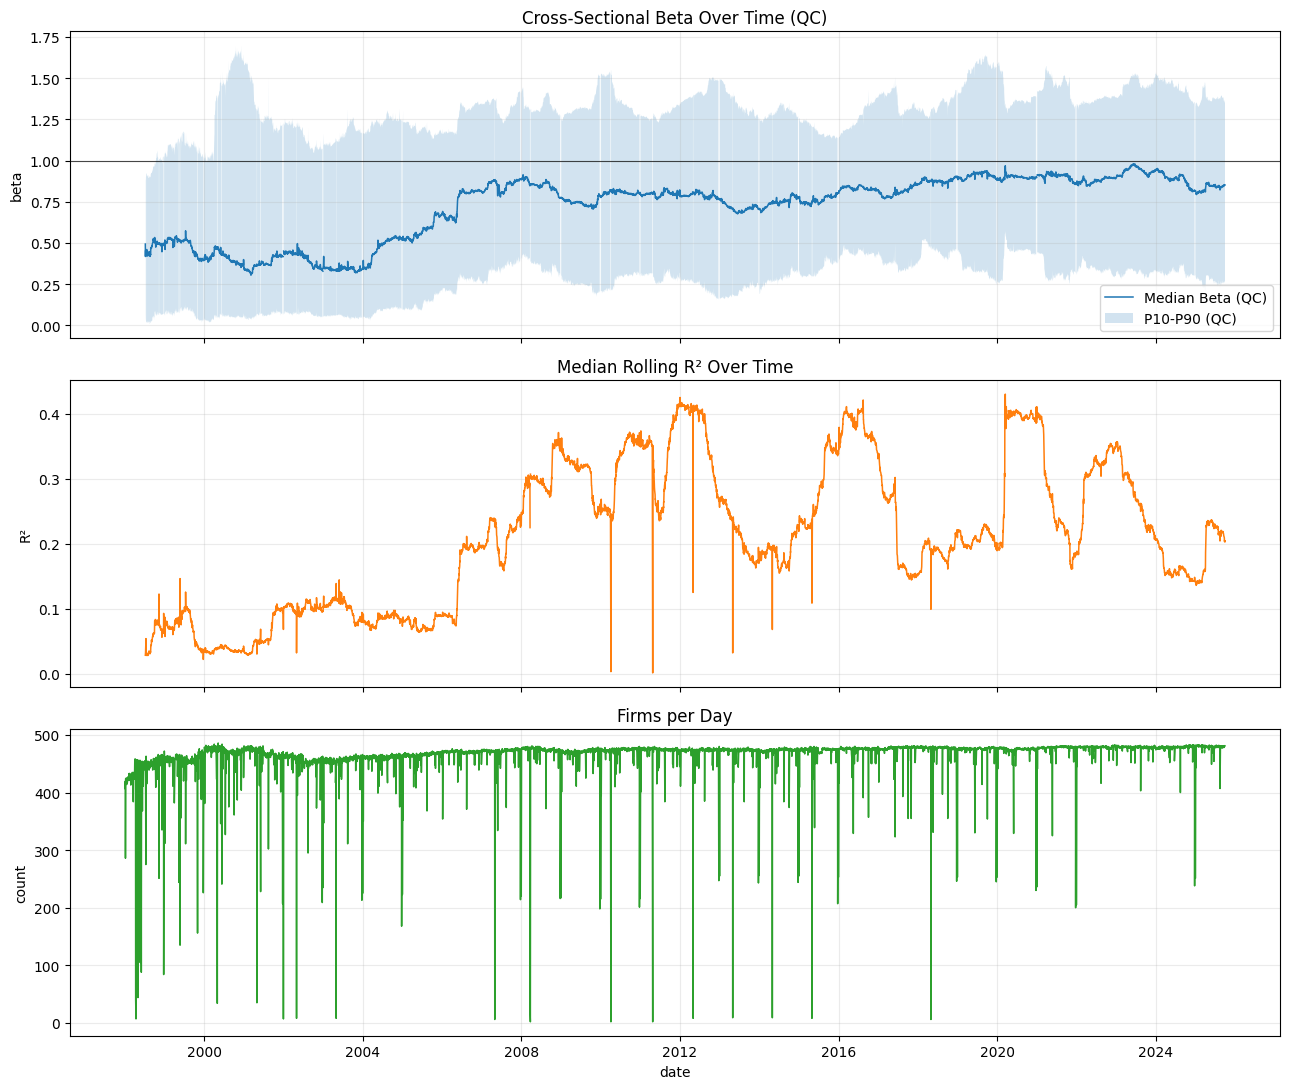

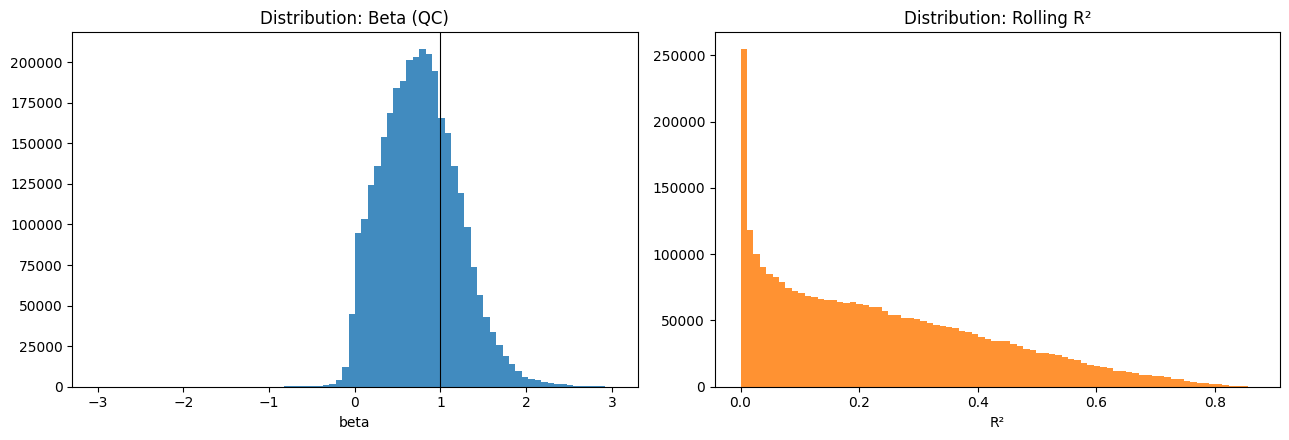

In [18]:
import matplotlib.pyplot as plt

plot_df = analysis_df.dropna(subset=["date"]).copy()

beta_daily_stats = (
    plot_df.groupby("date", as_index=False)
    .agg(
        beta_median=("beta", "median"),
        beta_p10=("beta", lambda s: s.quantile(0.10)),
        beta_p90=("beta", lambda s: s.quantile(0.90)),
        r2_median=("r2_capm_daily", "median"),
        n_firms=("n_firms_day", "max"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(beta_daily_stats["date"], beta_daily_stats["beta_median"], lw=1.1, label="Median Beta (QC)")
axes[0].fill_between(
    beta_daily_stats["date"],
    beta_daily_stats["beta_p10"],
    beta_daily_stats["beta_p90"],
    alpha=0.2,
    label="P10-P90 (QC)",
)
axes[0].axhline(1.0, color="black", lw=0.8, alpha=0.7)
axes[0].set_title("Cross-Sectional Beta Over Time (QC)")
axes[0].set_ylabel("beta")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(beta_daily_stats["date"], beta_daily_stats["r2_median"], color="tab:orange", lw=1.1)
axes[1].set_title("Median Rolling R² Over Time")
axes[1].set_ylabel("R²")
axes[1].grid(alpha=0.25)

axes[2].plot(beta_daily_stats["date"], beta_daily_stats["n_firms"], color="tab:green", lw=1.1)
axes[2].set_title("Firms per Day")
axes[2].set_ylabel("count")
axes[2].set_xlabel("date")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(plot_df["beta"].dropna(), bins=80, color="tab:blue", alpha=0.85)
axes[0].axvline(1.0, color="black", lw=0.8)
axes[0].set_title("Distribution: Beta (QC)")
axes[0].set_xlabel("beta")

axes[1].hist(plot_df["r2_capm_daily"].dropna(), bins=80, color="tab:orange", alpha=0.85)
axes[1].set_title("Distribution: Rolling R²")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()
